In [1]:
import pandas as pd
import numpy as np
import os
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)
from datasets import Dataset
import matplotlib.pyplot as plt
import seaborn as sns
import time

RANDOM_STATE = 42
print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
#Loading dataset
data_path = "../data/processed_data/clean_news_data.csv"
print("Clean path file:", data_path)

Clean path file: ../data/processed_data/clean_news_data.csv


In [3]:
if not os.path.exists (data_path):
    data_path = None

if data_path is None:
    raise FileNotFoundError(
        "clean_news_data.csv were not found."
    )
df = pd.read_csv(data_path)
print("Shape of clean dataset : ",df.shape)

df = df.dropna(subset=["clean_text"]).reset_index(drop=True)
print("Number of nulls in clean_text:", df["clean_text"].isnull().sum())

Shape of clean dataset :  (38322, 2)
Number of nulls in clean_text: 0


In [4]:
X = df['clean_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.20,
    random_state = RANDOM_STATE,
    stratify = y
)

print("Training samples: ",len(X_train))
print("Testing samples: ",len(X_test))

Training samples:  30657
Testing samples:  7665


In [5]:
# Check types and nulls in X_train
print("Total items:", len(X_train))
print("Nulls:", sum(1 for x in X_train if x is None or (isinstance(x, float) and np.isnan(x))))
print("Non-strings:", sum(1 for x in X_train if not isinstance(x, str)))

# Show a few non-string examples
bad = [x for x in X_train if not isinstance(x, str)]
print("Examples of non-strings:", bad[:5])


Total items: 30657
Nulls: 0
Non-strings: 0
Examples of non-strings: []


In [6]:
# Clean up X_train and X_test: force to string, remove NaNs
X_train = [str(x).strip() for x in X_train if x is not None and pd.notna(x)]
X_test  = [str(x).strip() for x in X_test  if x is not None and pd.notna(x)]

# The lengths of X and y must match — so filter y the same way
# Easier approach: do it on the dataframe BEFORE split

In [7]:
MODEL_NAME = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Tokenize the data
train_encodings = tokenizer(X_train, truncation=True, padding=True, max_length=256)
test_encodings = tokenizer(X_test, truncation=True, padding=True, max_length=256)

print("Samples:", len(train_encodings["input_ids"]))
print("First 20 token IDs:", train_encodings["input_ids"][0][:20])

Samples: 30657
First 20 token IDs: [101, 12058, 1999, 1057, 1055, 7402, 3789, 2071, 2022, 26475, 1999, 4883, 2602, 5002, 3951, 4883, 4018, 6221, 8398, 1055]


In [12]:
class FakeNewsDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = FakeNewsDataset(train_encodings, y_train.tolist())
test_dataset = FakeNewsDataset(test_encodings, y_test.tolist())

print("Train dataset size:", len(train_dataset))
print("Test dataset size :", len(test_dataset))
print("Keys in one item  :", list(train_dataset[0].keys()))
print("Label of first    :", train_dataset[0]["labels"].item())
print("Input shape       :", train_dataset[0]["input_ids"].shape)


Train dataset size: 30657
Test dataset size : 7665
Keys in one item  : ['input_ids', 'token_type_ids', 'attention_mask', 'labels']
Label of first    : 1
Input shape       : torch.Size([256])


In [13]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model loaded. Parameters: {total_params:,}")


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded. Parameters: 66,955,010


In [14]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    """Compute accuracy, precision, recall, F1 for the Trainer."""
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average="binary"
    )
    acc = accuracy_score(labels, predictions)
    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

# Use MPS (Apple Silicon) if available, otherwise CPU
if torch.backends.mps.is_available():
    device_name = "mps"
elif torch.cuda.is_available():
    device_name = "cuda"
else:
    device_name = "cpu"

print(f"Training will use: {device_name}")

OUTPUT_DIR = "../models/distilbert_fake_news"

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=3,
    per_device_train_batch_size=8,        # reduce to 4 if you run out of memory
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_steps=200,
    save_total_limit=2,                   # keep only best 2 checkpoints to save disk
    report_to="none",
)

print("Training arguments configured.")
print(f"  Epochs: {training_args.num_train_epochs}")
print(f"  Batch size: {training_args.per_device_train_batch_size}")
print(f"  Learning rate: {training_args.learning_rate}")


Training will use: mps
Training arguments configured.
  Epochs: 3
  Batch size: 8
  Learning rate: 2e-05


In [15]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

print("Starting training... (this may take 1-2 hours on CPU)")
start_time = time.time()

trainer.train()

elapsed = time.time() - start_time
minutes = elapsed / 60
print(f"\nTraining completed in {minutes:.1f} minutes")

Starting training... (this may take 1-2 hours on CPU)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.056795,0.028294,0.992564,0.989331,0.997133,0.993217
2,0.027414,0.024077,0.994521,0.992628,0.997372,0.994994
3,0.000030,0.028085,0.995956,0.994759,0.997849,0.996302


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/rahulkumar/Desktop/fake-news-classifier/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/rahulkumar/Desktop/fake-news-classifier/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Training completed in 125.4 minutes


In [16]:
print("Evaluating on test set...")
results = trainer.evaluate()

print("\n" + "=" * 50)
print("DISTILBERT TEST RESULTS")
print("=" * 50)
for key, value in results.items():
    if key.startswith("eval_"):
        name = key.replace("eval_", "")
        print(f"  {name:15s}: {value:.4f}")



Evaluating on test set...


/Users/rahulkumar/Desktop/fake-news-classifier/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.000030,0.028085,3,0.995956,0.994759,0.997849,0.996302



DISTILBERT TEST RESULTS
  loss           : 0.0281
  accuracy       : 0.9960
  precision      : 0.9948
  recall         : 0.9978
  f1             : 0.9963


/Users/rahulkumar/Desktop/fake-news-classifier/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


CLASSIFICATION REPORT
              precision    recall  f1-score   support

        FAKE       1.00      0.99      1.00      3480
        REAL       0.99      1.00      1.00      4185

    accuracy                           1.00      7665
   macro avg       1.00      1.00      1.00      7665
weighted avg       1.00      1.00      1.00      7665



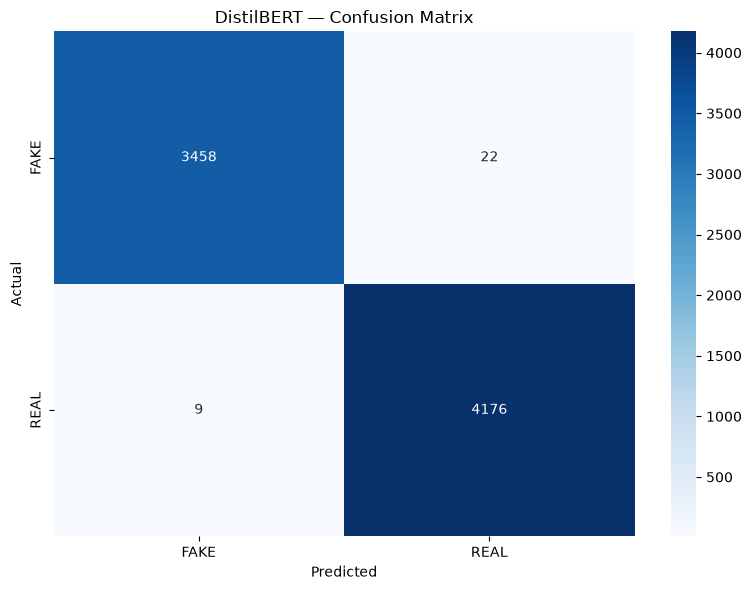

Confusion matrix saved to reports/distilbert_confusion_matrix.png


In [17]:

# Get predictions
predictions_output = trainer.predict(test_dataset)
preds = np.argmax(predictions_output.predictions, axis=-1)
labels = predictions_output.label_ids

# Classification Report
print("=" * 50)
print("CLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(labels, preds, target_names=["FAKE", "REAL"]))

# Confusion Matrix
cm = confusion_matrix(labels, preds)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["FAKE", "REAL"],
    yticklabels=["FAKE", "REAL"],
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("DistilBERT — Confusion Matrix")
plt.tight_layout()
plt.savefig("../reports/distilbert_confusion_matrix.png", dpi=150)
plt.show()
print("Confusion matrix saved to reports/distilbert_confusion_matrix.png")


In [18]:
SAVE_DIR = "../models/distilbert_fake_news"
os.makedirs(SAVE_DIR, exist_ok=True)

model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

print(f"Model saved to {SAVE_DIR}")
print("Files saved:")
for f in os.listdir(SAVE_DIR):
    size = os.path.getsize(os.path.join(SAVE_DIR, f))
    print(f"  {f:40s}  {size / 1024 / 1024:.1f} MB")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to ../models/distilbert_fake_news
Files saved:
  model.safetensors                         255.4 MB
  .DS_Store                                 0.0 MB
  tokenizer_config.json                     0.0 MB
  config.json                               0.0 MB
  tokenizer.json                            0.7 MB
  checkpoint-11499                          0.0 MB
  checkpoint-7666                           0.0 MB


In [19]:
import torch.nn.functional as F

def predict_single(text, model, tokenizer):
    """Predict FAKE or REAL for a single article."""
    model.eval()
    device = next(model.parameters()).device
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=256, padding=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        logits = model(**inputs).logits

    probs = F.softmax(logits, dim=-1).cpu().numpy()[0]
    pred = int(np.argmax(probs))
    label = "REAL" if pred == 1 else "FAKE"
    return label, probs[pred], probs

# Test with sample texts
test_texts = [
    "WASHINGTON (Reuters) - The Senate approved the new healthcare bill on Tuesday.",
    "BREAKING: You won't BELIEVE what the government is hiding from you!!!",
    "Scientists at MIT have developed a new method for detecting deepfakes in images.",
    "EXPOSED: Secret plot to destroy America revealed by anonymous insider!!!",
]

print("=" * 70)
print("QUICK PREDICTION TEST")
print("=" * 70)
for text in test_texts:
    label, confidence, probs = predict_single(text, model, tokenizer)
    print(f"\n  Text: {text[:80]}...")
    print(f"  Prediction: {label} ({confidence * 100:.1f}%)")
    print(f"  Probabilities: FAKE={probs[0]:.3f}, REAL={probs[1]:.3f}")



QUICK PREDICTION TEST

  Text: WASHINGTON (Reuters) - The Senate approved the new healthcare bill on Tuesday....
  Prediction: FAKE (99.1%)
  Probabilities: FAKE=0.991, REAL=0.009

  Text: BREAKING: You won't BELIEVE what the government is hiding from you!!!...
  Prediction: FAKE (100.0%)
  Probabilities: FAKE=1.000, REAL=0.000

  Text: Scientists at MIT have developed a new method for detecting deepfakes in images....
  Prediction: REAL (94.1%)
  Probabilities: FAKE=0.059, REAL=0.941

  Text: EXPOSED: Secret plot to destroy America revealed by anonymous insider!!!...
  Prediction: FAKE (100.0%)
  Probabilities: FAKE=1.000, REAL=0.000


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Attention on a FAKE-style article:
  Attention layers returned: 6


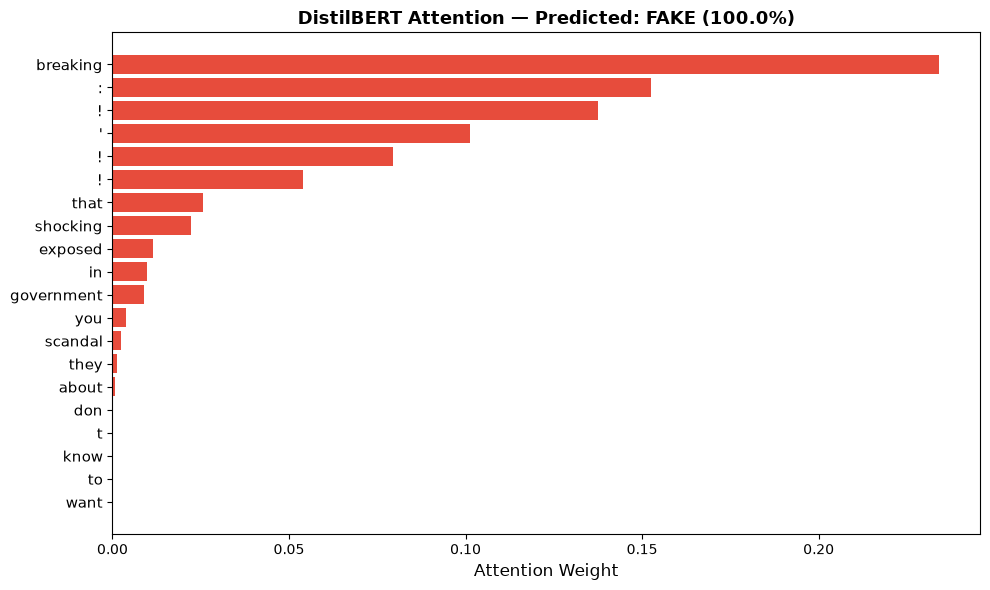


Attention on a REAL-style article:
  Attention layers returned: 6


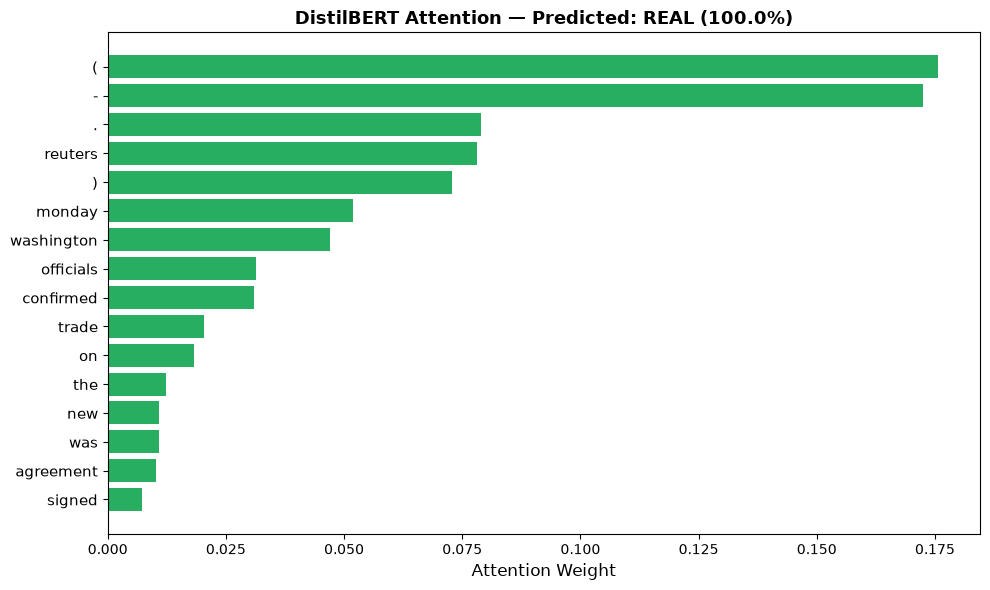

In [22]:
import torch.nn.functional as F
from transformers import AutoModelForSequenceClassification, AutoTokenizer

# Reload model with eager attention (needed to extract attention weights)
SAVE_DIR = "../models/distilbert_fake_news"
model_eager = AutoModelForSequenceClassification.from_pretrained(
    SAVE_DIR, attn_implementation="eager"
)
model_eager.eval()

device = next(model.parameters()).device
model_eager.to(device)

def visualize_attention(text, model_attn, tokenizer, layer=-1):
    """
    Extract and visualize attention weights from DistilBERT.
    """
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=128, padding=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model_attn(**inputs, output_attentions=True)

    # Verify attentions are returned
    print(f"  Attention layers returned: {len(outputs.attentions)}")

    attention = outputs.attentions[layer]
    avg_attention = attention.mean(dim=1).squeeze(0).cpu().numpy()

    # CLS token's attention to all other tokens
    cls_attention = avg_attention[0]

    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0].cpu())

    valid = [(tok, att) for tok, att in zip(tokens, cls_attention)
             if tok not in ["[CLS]", "[SEP]", "[PAD]"]]

    if not valid:
        print("No valid tokens found.")
        return

    words, scores = zip(*valid)

    logits = outputs.logits
    probs = F.softmax(logits, dim=-1).cpu().numpy()[0]
    pred_label = "REAL" if np.argmax(probs) == 1 else "FAKE"

    top_k = min(20, len(words))
    sorted_indices = np.argsort(scores)[::-1][:top_k]
    top_words = [words[i] for i in sorted_indices]
    top_scores = [scores[i] for i in sorted_indices]

    fig, ax = plt.subplots(figsize=(10, 6))
    colors = ["#e74c3c" if pred_label == "FAKE" else "#27ae60"] * top_k
    ax.barh(range(top_k), top_scores[::-1], color=colors[::-1])
    ax.set_yticks(range(top_k))
    ax.set_yticklabels(top_words[::-1], fontsize=11)
    ax.set_xlabel("Attention Weight", fontsize=12)
    ax.set_title(f"DistilBERT Attention — Predicted: {pred_label} ({probs.max()*100:.1f}%)",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("../reports/attention_visualization.png", dpi=150)
    plt.show()

# Test with the reloaded eager model
print("Attention on a FAKE-style article:")
visualize_attention(
    "BREAKING: Government EXPOSED in shocking scandal that they don't want you to know about!!!",
    model_eager, tokenizer
)

print("\nAttention on a REAL-style article:")
visualize_attention(
    "Washington (Reuters) - Officials confirmed the new trade agreement was signed on Monday.",
    model_eager, tokenizer
)

FINAL MODEL COMPARISON
              Model Accuracy Precision Recall F1 Score
Logistic Regression   0.9840    0.9806 0.9902   0.9854
      Random Forest   0.9649    0.9698 0.9658   0.9678
         DistilBERT   0.9960    0.9948 0.9978   0.9963



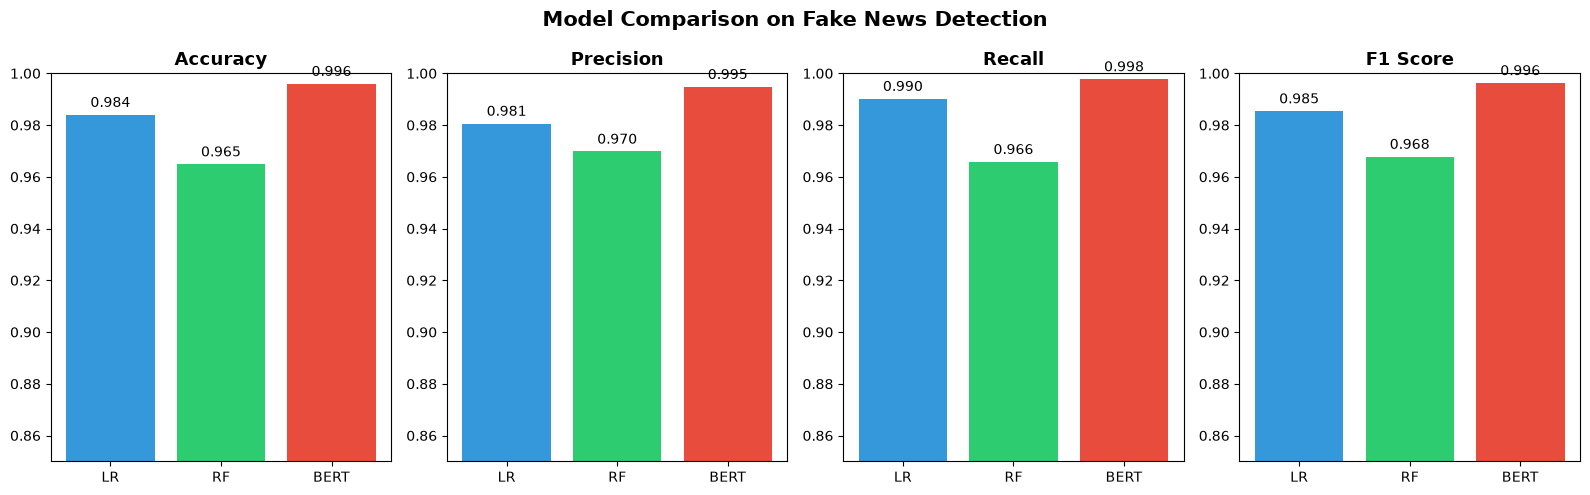

Comparison chart saved to reports/model_comparison.png


In [24]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import joblib
# --- Load baseline models ---
tfidf = joblib.load("../models/tfidf_vectorizer.pkl")
lr_model = joblib.load("../models/logistic_regression.pkl")
rf_model = joblib.load("../models/random_forest.pkl")

# --- Prepare test data for baselines ---
X_test_tfidf = tfidf.transform(X_test)

# --- Baseline predictions ---
lr_preds = lr_model.predict(X_test_tfidf)
rf_preds = rf_model.predict(X_test_tfidf)

# --- DistilBERT predictions (already computed above) ---
bert_preds = preds  # from Cell 13

# --- Build comparison table ---
def get_metrics(y_true, y_pred, name):
    return {
        "Model": name,
        "Accuracy": f"{accuracy_score(y_true, y_pred):.4f}",
        "Precision": f"{precision_score(y_true, y_pred):.4f}",
        "Recall": f"{recall_score(y_true, y_pred):.4f}",
        "F1 Score": f"{f1_score(y_true, y_pred):.4f}",
    }

comparison = pd.DataFrame([
    get_metrics(y_test, lr_preds, "Logistic Regression"),
    get_metrics(y_test, rf_preds, "Random Forest"),
    get_metrics(labels, bert_preds, "DistilBERT"),
])

print("=" * 70)
print("FINAL MODEL COMPARISON")
print("=" * 70)
print(comparison.to_string(index=False))
print()

# --- Bar chart ---
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]
colors = ["#3498db", "#2ecc71", "#e74c3c"]

for ax, metric in zip(axes, metrics):
    values = [float(comparison.loc[i, metric]) for i in range(3)]
    bars = ax.bar(["LR", "RF", "BERT"], values, color=colors)
    ax.set_title(metric, fontsize=13, fontweight="bold")
    ax.set_ylim(0.85, 1.0)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                f"{val:.3f}", ha="center", fontsize=10)

plt.suptitle("Model Comparison on Fake News Detection", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/model_comparison.png", dpi=150)
plt.show()
print("Comparison chart saved to reports/model_comparison.png")
